In [50]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
import statsmodels.api as sm
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import logit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

import os
import sys
utils_path = os.path.abspath(
    os.path.join(os.getcwd(), '..', '2_data_analysis', 'utils')
)

sys.path.append(utils_path)

import plot_style


# ── Palette and style ────────────────────────────────────────────────────────
C_AGR   = '#C0392B'   # steel blue  — with acuerdo
C_NOAGR = '#2C6E8A'   # muted red   — without acuerdo

## **Conflict Panel**

---

In [51]:
df_panel = pd.read_csv('../../data/output/conflict_level/conflict_panel.csv', low_memory=False)
df_panel_quarterly = pd.read_csv('../../data/output/conflict_level/conflict_panel_quarters.csv')
#select the treated conflicts that were defines for csdid
active_conflicts = df_panel_quarterly[df_panel_quarterly['first_agreement']==1]['conflict_id'].unique()

#replace the column ever_agreement in conflict_level with 1 only for those conflicts that are in active_conflicts
df_panel['ever_agreement'] = df_panel.apply(lambda row: 1 if row['conflict_id'] in active_conflicts else 0, axis=1)

print(f"Total conflicts: {len(df_panel['conflict_id'].unique())}")
print(f"With agreement:   {df_panel.loc[df_panel['ever_agreement']==1]['conflict_id'].nunique()}")
print(f"Without agreement: {df_panel.loc[df_panel['ever_agreement']==0]['conflict_id'].nunique()}")


Total conflicts: 201
With agreement:   66
Without agreement: 135


In [52]:
df_panel[['conflict_id', 'year_mo', 'n_events', 'n_factions']]

,conflict_id,year_mo,n_events,n_factions
0,205,1989-01,0.0,NaN
1,205,1989-02,0.0,NaN
2,205,1989-03,0.0,NaN
3,205,1989-04,0.0,NaN
4,205,1989-05,0.0,NaN
...,...,...,...,...
86827,16379,2024-08,0.0,NaN
86828,16379,2024-09,0.0,NaN
86829,16379,2024-10,0.0,NaN
86830,16379,2024-11,0.0,NaN


## **UCDP - Incompatibility Type**

---

In [53]:
#merge the incompatibility column from UCDP/PRIO
df_prio = pd.read_csv('../../data/input/ucdp/UcdpPrioConflict_v25_1.csv', low_memory=False)
df_panel = df_panel.merge(df_prio[['conflict_id', 'year', 'incompatibility', 'type_of_conflict']], left_on = ['conflict_id', 'year'], right_on = ['conflict_id', 'year'], how = 'left')
df_panel['incompatibility'] = df_panel.groupby('conflict_id')['incompatibility'].ffill().bfill().astype(int)
type_of_conflict_map = {1: "extrasystemic", 2: "intrastate", 3: "interstate", 4: "internationalized_intrastate"}
df_panel['type_of_conflict'] = df_panel.groupby('conflict_id')['type_of_conflict'].ffill().bfill().map(type_of_conflict_map)
df_panel[['conflict_id', 'year_mo', 'incompatibility', 'type_of_conflict']]

,conflict_id,year_mo,incompatibility,type_of_conflict
0,205,1989-01,1,interstate
1,205,1989-02,1,interstate
2,205,1989-03,1,interstate
3,205,1989-04,1,interstate
4,205,1989-05,1,interstate
...,...,...,...,...
86827,16379,2024-08,1,interstate
86828,16379,2024-09,1,interstate
86829,16379,2024-10,1,interstate
86830,16379,2024-11,1,interstate


## **UCDP - Number of Factions**

---

In [54]:
from functions.build_number_factions import (
    build_faction_variables
)

df_panel = build_faction_variables(
    df_panel,
    "../../data/input/ucdp/Dyadic_v25_1.csv")

df_panel[['conflict_id', 'year_mo', 'n_factions_combined']]

,conflict_id,year_mo,n_factions_combined
0,205,1989-01,NaN
1,205,1989-02,NaN
2,205,1989-03,NaN
3,205,1989-04,NaN
4,205,1989-05,NaN
...,...,...,...
86827,16379,2024-08,1.0
86828,16379,2024-09,1.0
86829,16379,2024-10,1.0
86830,16379,2024-11,1.0


## **UCDP - Termination Conflict Type**

---

In [55]:
from functions.build_conflict_termination import (
    build_conflict_termination
)

df_panel = build_conflict_termination(
    df_panel,
    "../../data/input/ucdp/UCDPConflictTerminationDataset_v4_2024_Conflict.csv"
)

df_panel[['conflict_id', 'year_mo', 'termination_outcome_label', 'termination_outcome_group']]

,conflict_id,year_mo,termination_outcome_label,termination_outcome_group
0,205,1989-01,Low activity,Low activity
1,205,1989-02,Low activity,Low activity
2,205,1989-03,Low activity,Low activity
3,205,1989-04,Low activity,Low activity
4,205,1989-05,Low activity,Low activity
...,...,...,...,...
86827,16379,2024-08,Ongoing / censored,Ongoing / censored
86828,16379,2024-09,Ongoing / censored,Ongoing / censored
86829,16379,2024-10,Ongoing / censored,Ongoing / censored
86830,16379,2024-11,Ongoing / censored,Ongoing / censored


In [56]:
termination = pd.read_csv("../../data/input/ucdp/UCDPConflictTerminationDataset_v4_2024_Conflict.csv")
termination

,conflict_id,location,side_a,side_a_id,side_a_2nd,side_b,side_b_id,side_b_2nd,incompatibility,territory_name,...,c_epno,c_ep_startyear,c_epterm,c_outcome,c_ep_endyear,c_ependdate,c_ependprec,c_ep_durcount,c_ep_dur,version
0,200,Bolivia,Government of Bolivia,23,NaN,Popular Revolutionary Movement,719,NaN,2,NaN,...,1,1946,1.0,4.0,1946.0,1946-07-21,1.0,1,1.0,4.2024
1,200,Bolivia,Government of Bolivia,23,NaN,MNR,720,NaN,2,NaN,...,2,1949,1.0,3.0,1949.0,1949-09-16,1.0,1,1.0,4.2024
2,200,Bolivia,Government of Bolivia,23,NaN,MNR,720,NaN,2,NaN,...,3,1952,1.0,4.0,1952.0,1952-04-12,1.0,1,1.0,4.2024
3,200,Bolivia,Government of Bolivia,23,NaN,ELN,721,NaN,2,NaN,...,4,1967,1.0,3.0,1967.0,1967-10-16,1.0,1,1.0,4.2024
4,201,Cambodia (Kampuchea),Government of France,33,NaN,Khmer Issarak,160,NaN,1,Cambodia,...,1,1946,0.0,NaN,NaN,NaN,NaN,1,NaN,4.2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2747,16069,Ethiopia,Government of Ethiopia,97,NaN,Fano,8118,NaN,3,Amhara,...,1,2023,NaN,NaN,NaN,NaN,NaN,2,NaN,4.2024
2748,16099,"United Kingdom, United States of America, Yeme...","Government of United Kingdom, Government of Un...","28, 3","Government of Australia, Government of Bahrain...",Government of Yemen (North Yemen),123,NaN,1,"Red Sea, Bab al Mandab and Gulf of Aden",...,1,2024,NaN,NaN,NaN,NaN,NaN,1,NaN,4.2024
2749,16292,Tajikistan,Government of Tajikistan,131,NaN,IS,234,NaN,1,Islamic State,...,1,2018,0.0,NaN,NaN,NaN,NaN,1,NaN,4.2024
2750,16292,Tajikistan,Government of Tajikistan,131,NaN,IS,234,NaN,1,Islamic State,...,1,2018,1.0,5.0,2019.0,2019-12-31,5.0,2,2.0,4.2024


## **UCDP - Experience Fighting**
---

In [57]:
from functions.build_experience import (
    build_experience
)
from functions.build_experience_compound import build_experience_expanded


df_panel = build_experience(
    df_panel,
    "../../data/input/ucdp/Dyadic_v25_1.csv",
    delta=0.95
)

df_panel = build_experience_expanded(
    df_panel,
    "../../data/input/ucdp/Dyadic_v25_1.csv",
    delta=0.95,
    weight_direct=1.0,
    weight_government=0.5,
)

df_panel[['conflict_id', 'year_mo', 'experience', 'experience_total', 'exp_direct', 'exp_government']]

Experience computed for 201 conflicts:
  exp_direct = 0 in 133/201 conflicts (66%)
  experience_total = 0 in 77/201 conflicts (38%)
  (fewer zeros = more variation for IA proxy)


,conflict_id,year_mo,experience,experience_total,exp_direct,exp_government
0,205,1989-01,8.270352,12.164151,8.270352,7.787599
1,205,1989-02,8.270352,12.164151,8.270352,7.787599
2,205,1989-03,8.270352,12.164151,8.270352,7.787599
3,205,1989-04,8.270352,12.164151,8.270352,7.787599
4,205,1989-05,8.270352,12.164151,8.270352,7.787599
...,...,...,...,...,...,...
86827,16379,2024-08,0.000000,7.250709,0.000000,14.501418
86828,16379,2024-09,0.000000,7.250709,0.000000,14.501418
86829,16379,2024-10,0.000000,7.250709,0.000000,14.501418
86830,16379,2024-11,0.000000,7.250709,0.000000,14.501418


In [58]:
df_panel[['conflict_id', 'year_mo', 'n_events', 'n_factions_combined']]

,conflict_id,year_mo,n_events,n_factions_combined
0,205,1989-01,0.0,NaN
1,205,1989-02,0.0,NaN
2,205,1989-03,0.0,NaN
3,205,1989-04,0.0,NaN
4,205,1989-05,0.0,NaN
...,...,...,...,...
86827,16379,2024-08,0.0,1.0
86828,16379,2024-09,0.0,1.0
86829,16379,2024-10,0.0,1.0
86830,16379,2024-11,0.0,1.0


## **Vdem Variables**

---

In [59]:
from functions.build_vdem_variables import (
    build_vdem_dataset,
    merge_vdem_to_panel
)

# Build VDEM
df_vdem = build_vdem_dataset(
    "../../data/input/v_dem/V-Dem-CY-Full+Others-v16.csv"
)

#rolling window columns 
VDEM_ROLLING_VARS = [
    "vdem_state_territorial_control",
    "vdem_horizontal_accountability",
    "vdem_judicial_constraints",
    "vdem_legislative_constraints",
    "vdem_neopatrimonial",
    "vdem_clientelism",
    "vdem_predictable_enforcement",
    "vdem_wb_political_stability",
    "vdem_wb_government_effectiveness",
    "vdem_public_adm_capacity",

]
VDEM_ROLLING_VARS_mean_lag5 = [var + "_pre5y" for var in VDEM_ROLLING_VARS]


# variables to merge
VDEM_columns = ['cow_code','year','vdem_state_territorial_control','vdem_neopatrimonial','vdem_horizontal_accountability',
        'vdem_judicial_constraints','vdem_legislative_constraints', 'vdem_regime_type', "vdem_predictable_enforcement", 
         "vdem_wb_political_stability",  "vdem_wb_government_effectiveness", "vdem_public_adm_capacity"]

# Merge into panel
df_panel = merge_vdem_to_panel(
    df_panel,
    df_vdem,
    VDEM_columns + VDEM_ROLLING_VARS_mean_lag5,
    "../../data/input/ucdp/GEDEvent_v25_1.csv"
)

df_panel[['conflict_id', 'year_mo']+VDEM_columns+VDEM_ROLLING_VARS_mean_lag5]

/Users/luciasauer/Library/CloudStorage/GoogleDrive-lucia.sauer@bse.eu/Mi unidad/EconAI/1_agreements_violence/agreements_violence/src/5_structural_model/functions/build_vdem_variables.py:203: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


,conflict_id,year_mo,cow_code,year,vdem_state_territorial_control,vdem_neopatrimonial,vdem_horizontal_accountability,vdem_judicial_constraints,vdem_legislative_constraints,vdem_regime_type,...,vdem_state_territorial_control_pre5y,vdem_horizontal_accountability_pre5y,vdem_judicial_constraints_pre5y,vdem_legislative_constraints_pre5y,vdem_neopatrimonial_pre5y,vdem_clientelism_pre5y,vdem_predictable_enforcement_pre5y,vdem_wb_political_stability_pre5y,vdem_wb_government_effectiveness_pre5y,vdem_public_adm_capacity_pre5y
0,205,1989-01,630.0,1989,91.667,0.744,0.161,0.146,0.627,1.0,...,92.3334,0.1646,0.1460,0.5926,0.7424,0.3558,-0.4256,NaN,NaN,-1.2510
1,205,1989-02,630.0,1989,91.667,0.744,0.161,0.146,0.627,1.0,...,92.3334,0.1646,0.1460,0.5926,0.7424,0.3558,-0.4256,NaN,NaN,-1.2510
2,205,1989-03,630.0,1989,91.667,0.744,0.161,0.146,0.627,1.0,...,92.3334,0.1646,0.1460,0.5926,0.7424,0.3558,-0.4256,NaN,NaN,-1.2510
3,205,1989-04,630.0,1989,91.667,0.744,0.161,0.146,0.627,1.0,...,92.3334,0.1646,0.1460,0.5926,0.7424,0.3558,-0.4256,NaN,NaN,-1.2510
4,205,1989-05,630.0,1989,91.667,0.744,0.161,0.146,0.627,1.0,...,92.3334,0.1646,0.1460,0.5926,0.7424,0.3558,-0.4256,NaN,NaN,-1.2510
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86827,16379,2024-08,520.0,2024,61.200,0.806,0.243,0.208,0.609,0.0,...,63.6352,0.3224,0.1766,0.6540,0.8256,0.7944,-0.5312,NaN,NaN,-0.6058
86828,16379,2024-09,520.0,2024,61.200,0.806,0.243,0.208,0.609,0.0,...,63.6352,0.3224,0.1766,0.6540,0.8256,0.7944,-0.5312,NaN,NaN,-0.6058
86829,16379,2024-10,520.0,2024,61.200,0.806,0.243,0.208,0.609,0.0,...,63.6352,0.3224,0.1766,0.6540,0.8256,0.7944,-0.5312,NaN,NaN,-0.6058
86830,16379,2024-11,520.0,2024,61.200,0.806,0.243,0.208,0.609,0.0,...,63.6352,0.3224,0.1766,0.6540,0.8256,0.7944,-0.5312,NaN,NaN,-0.6058


In [60]:
pd.crosstab(
    index=df_panel["termination_outcome_group"],
    columns=df_panel['ever_agreement'],
    values=df_panel['conflict_id'],
    aggfunc="nunique",
    dropna=False
)

ever_agreement,0,1
termination_outcome_group,,
Actor ceases,6,5
Agreement,6,15
Ceasefire,11,12
Low activity,54,15
Military victory,39,11
Ongoing / censored,19,8


In [61]:
print(df_panel.loc[(df_panel['ever_agreement']==0) & (df_panel['termination_outcome_group']=='Agreement')]['conflict_id'].unique())
print(df_panel.loc[(df_panel['ever_agreement']==0) & (df_panel['termination_outcome_group']=='Ceasefire')]['conflict_id'].unique())

[  287   298   372   373   379 11348]
[  223   274   292   315   322   347   354   365   425   430 14074]


## **Conflict Level Dataset**

1. create indicies with the variables applying PCA
2. Aggregate to the conflict_level

In [62]:
df_panel_capped = df_panel[(df_panel['year_mo']>=df_panel['start_date']) & (df_panel['year_mo']<=df_panel['end_date'])]
pre_treatment = df_panel_capped[((df_panel_capped["first_agreement_date"] == 0) | (df_panel_capped["year_mo_numeric"]<=df_panel_capped["first_agreement_date"]))].copy()
pre_treatment = pre_treatment.sort_values(["conflict_id", "year_mo_numeric"])

conflict_level = (
    pre_treatment.groupby('conflict_id')
    .agg(
        country                  = ('country', 'first'),
        region                   = ('region', 'first'),
        incompatibility          = ('incompatibility', 'first'),
        governmental             = ('incompatibility', lambda x: (x == 2).any().astype(int)),
        territorial             = ('incompatibility', lambda x: (x == 1).any().astype(int)),
        mean_factions            = ('n_factions_combined', 'mean'), #commit index proxy
        state_territorial_control= ('vdem_state_territorial_control', 'mean'), #commit index proxy must be inverted
        state_territorial_control_onset = ('vdem_state_territorial_control', 'first'), #value of state territorial control at the start_date of the conflict
        state_territorial_control_pre5y = ('vdem_state_territorial_control_pre5y', 'first'), #value of state territorial control in the 5 years before the start_date of the conflict
        neopatrimonial           = ('vdem_neopatrimonial', 'mean'), #commit index proxy: personalist regimes (more value, more commit problems)
        neopatrimonial_onset     = ('vdem_neopatrimonial', 'first'), #value of neopatrimonial at the start_date of the conflict
        neopatrimonial_pre5y     = ('vdem_neopatrimonial_pre5y', 'first'), #value of neopatrimonial in the 5 years before the start_date of the conflict
        horiz_accountability     = ('vdem_horizontal_accountability', 'mean'),
        horiz_accountability_onset = ('vdem_horizontal_accountability', 'first'), #value of horizontal accountability at the start_date of the conflict
        horiz_accountability_pre5y = ('vdem_horizontal_accountability_pre5y', 'first'), #value of horizontal accountability in the 5 years before the start_date of the conflict
        judicial_constraints     = ('vdem_judicial_constraints', 'mean'),
        judicial_constraints_onset = ('vdem_judicial_constraints', 'first'), #value of judicial constraints at the start_date of the conflict
        judicial_constraints_pre5y = ('vdem_judicial_constraints_pre5y', 'first'), #value of judicial constraints in the 5 years before the start_date of the conflict
        legislative_constraints  = ('vdem_legislative_constraints', 'mean'),
        legislative_constraints_onset  = ('vdem_legislative_constraints', 'first'), #value of legislative constraints at the start_date of the conflict
        legislative_constraints_pre5y  = ('vdem_legislative_constraints_pre5y', 'first'), #value of legislative constraints in the 5 years before the start_date of the conflict
        political_stability      = ('vdem_wb_political_stability', 'mean'),
        political_stability_onset = ('vdem_wb_political_stability', 'first'), #value of political stability at the start_date of the conflict
        political_stability_pre5y = ('vdem_wb_political_stability_pre5y', 'first'), #value of political stability in the 5 years before the start_date of the conflict
        predictable_enforcement = ('vdem_predictable_enforcement', 'mean'),
        predictable_enforcement_onset = ('vdem_predictable_enforcement', 'first'), #value of predictable enforcement at the start_date of the conflict
        predictable_enforcement_pre5y = ('vdem_predictable_enforcement_pre5y', 'first'), #value of predictable enforcement in the 5 years before the start_date of the conflict
        regime_type              = ('vdem_regime_type', lambda x: x.mode().iloc[0] if not x.mode().empty else None),
        regime_type_onset        = ('vdem_regime_type', lambda x: x.iloc[0]), #value of regime type at the start_date of the conflict
        experience_fighting      = ('experience', 'first'), #how many times the parties have fought before
        experience_total_fighting = ('experience_total', 'first'), #how many times the parties have fought before
        experience_direct        = ('exp_direct', 'first'), #how many times the parties have fought directly before
        experience_government    = ('exp_government', 'first'), #how many times the parties have fought on the government side before
        ever_agreement           = ('ever_agreement', 'max'),
        first_agreement_date     = ('first_agreement_date', 'max'),
        start_date_numeric       = ('start_date_numeric', 'first'),
        termination_outcome_group = ('termination_outcome_group', 'first'),
        termination_outcome_label = ('termination_outcome_label', 'first'),
        type_of_conflict         = ('type_of_conflict', 'first')
    )
    .reset_index()
)

conflict_level['total_deaths'] = pre_treatment.groupby('conflict_id')['best'].sum().values
conflict_level['log_total_deaths'] = np.log1p(conflict_level['total_deaths'])
conflict_level['peak_monthly_deaths'] = pre_treatment.groupby('conflict_id')['best'].max().values
conflict_level['duration_months'] = pre_treatment.groupby('conflict_id')['duration_months'].first().values
conflict_level['log_duration']     = np.log1p(conflict_level['duration_months'])
conflict_level['duration_years'] = conflict_level['duration_months'] / 12

conflict_level["months_to_agreement"] = np.where(conflict_level["ever_agreement"] == 1,(conflict_level["first_agreement_date"]-conflict_level["start_date_numeric"]),np.nan)

#count the number of conflicts per country and then append to conflit_level
pre_treatment['multiple_conflicts'] = pre_treatment.groupby('country')['conflict_id'].transform('nunique')
#generate a binary variable that indicates if there are multiple conflicts in the same country
pre_treatment['multiple_conflicts_binary'] = (pre_treatment['multiple_conflicts'] > 1).astype(int)
conflict_level = conflict_level.merge(pre_treatment.groupby('conflict_id')['multiple_conflicts_binary'].first().reset_index(),on='conflict_id',how='left')

# ============================================================
# Weakness indicators for commitment index
# ============================================================
#Invert the variables, so higher means more commitment problems
conflict_level["weak_state"] = (-conflict_level["state_territorial_control"])
conflict_level["weak_accountability"] = (-conflict_level["horiz_accountability"])
conflict_level["weak_legislative"] = (-conflict_level["legislative_constraints"])
conflict_level["weak_judicial"] = (-conflict_level["judicial_constraints"])


conflict_level = pd.get_dummies(conflict_level, columns=['region'], drop_first=True, dtype=int)
conflict_level.head()

,conflict_id,country,incompatibility,governmental,territorial,mean_factions,state_territorial_control,state_territorial_control_onset,state_territorial_control_pre5y,neopatrimonial,...,months_to_agreement,multiple_conflicts_binary,weak_state,weak_accountability,weak_legislative,weak_judicial,region_Americas,region_Asia,region_Europe,region_Middle East
0,205,Iran,1,0,1,1.000000,90.645253,91.667,92.2668,0.736464,...,NaN,1,-90.645253,-0.338875,-0.681860,-0.15189,0,0,0,1
1,209,Philippines,2,1,0,1.533333,91.167000,91.167,91.1670,0.417467,...,44.0,1,-91.167000,-0.811267,-0.781267,-0.77140,0,1,0,0
2,218,India,1,0,1,1.000000,95.500000,95.500,95.7000,0.280143,...,27.0,1,-95.500000,-1.115000,-0.842000,-0.80200,0,1,0,0
3,220,Paraguay,2,1,0,1.000000,87.600000,87.600,87.6000,0.929000,...,NaN,0,-87.600000,0.704000,-0.254000,-0.23600,1,0,0,0
4,221,Myanmar (Burma),1,0,1,1.133080,76.378982,79.000,74.6800,0.955309,...,274.0,1,-76.378982,1.684858,-0.379000,-0.04560,0,1,0,0


# **Indices**
---

## **PCA to CPI** 

In [63]:
conflict_level['regime_type'].describe()

count    201.000000
mean       0.945274
std        0.749660
min        0.000000
25%        0.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: regime_type, dtype: float64

In [64]:
from sklearn.preprocessing import MinMaxScaler

conflict_level["weak_state_preconflict"] = (-conflict_level["state_territorial_control_pre5y"]) #0-100
conflict_level["weak_accountability_preconflict"] = (-conflict_level["horiz_accountability_pre5y"])
conflict_level["weak_legislative_preconflict"] = (-conflict_level["legislative_constraints_pre5y"]) #0-1
conflict_level["weak_judicial_preconflict"] = (-conflict_level["judicial_constraints_pre5y"]) #0-1
conflict_level['weak_political_stability_preconflict'] = (-conflict_level["political_stability_pre5y"]) 

conflict_level['low_regime'] = -conflict_level['regime_type']
COMMIT_VARS = [
    "weak_state_preconflict",
    "weak_judicial_preconflict",
    "weak_legislative_preconflict",
    "weak_accountability_preconflict",
    "weak_political_stability_preconflict",
]

#fill missing values with the mean of each variable per conflict
conflict_level[COMMIT_VARS] = conflict_level[COMMIT_VARS].fillna(conflict_level[COMMIT_VARS].mean())

scaler = StandardScaler()
X_cp = scaler.fit_transform(
    conflict_level[COMMIT_VARS]
)


pca_cp = PCA(n_components=1)

conflict_level["commit_index"] = (
    pca_cp.fit_transform(X_cp)[:, 0]
)

loadings = pd.DataFrame(
    pca_cp.components_.T,
    columns=["PC1"],
    index=COMMIT_VARS
)

print(loadings)
print("\n Explained Variance Ratio:", pca_cp.explained_variance_ratio_)

min_max_scaler = MinMaxScaler()

conflict_level["commit_index"] = min_max_scaler.fit_transform(
    conflict_level[["commit_index"]]
)

conflict_level["high_commitment"] = np.where(
    conflict_level["commit_index"]>=conflict_level["commit_index"].median(),
    1,
    0
)

                                           PC1
weak_state_preconflict                0.271883
weak_judicial_preconflict             0.516832
weak_legislative_preconflict          0.531003
weak_accountability_preconflict       0.557138
weak_political_stability_preconflict  0.258064

 Explained Variance Ratio: [0.57979046]


## **Information Asymmetry Index (IAI)**

---

In [65]:
[c for c in conflict_level.columns if "experience" in c]

['experience_fighting',
 'experience_total_fighting',
 'experience_direct',
 'experience_government']

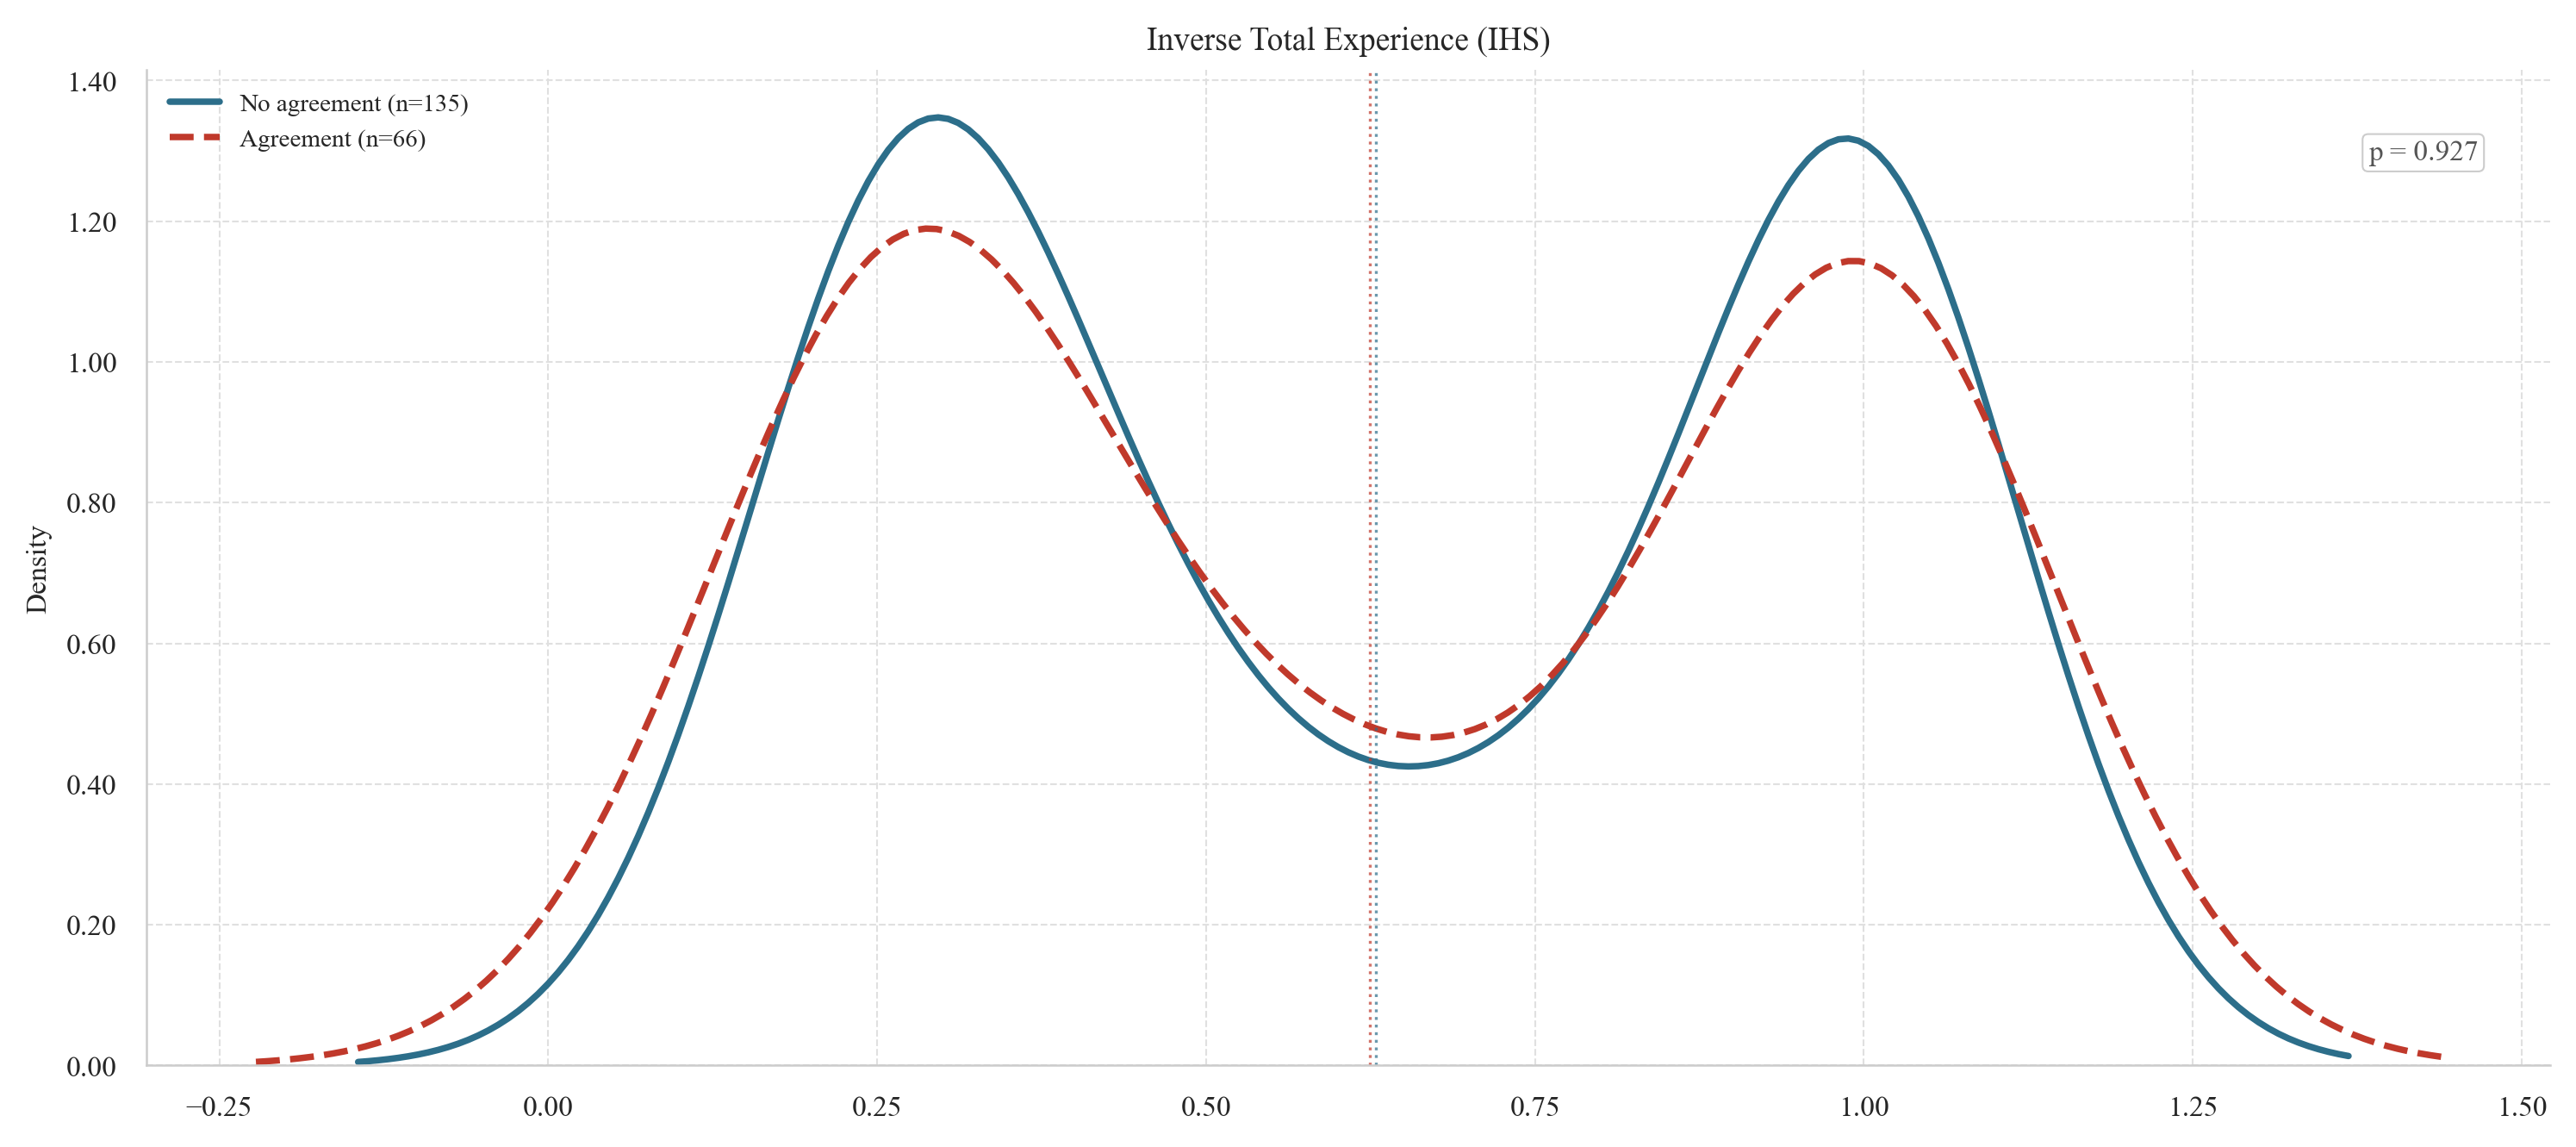

In [66]:
from functions.plot_functions import plot_kde_by_agreement
# ============================================================
# EXPERIENCE VARIABLES
# ============================================================
#experience is highly skewed, we can have a binary version
conflict_level["prior_interaction"] = (
    conflict_level["experience_total_fighting"] > 0
).astype(int)

#experience is highly skewed, we can have inverse hyperbolicsine transformation
conflict_level["experience_total_ihs"] = np.arcsinh(
    conflict_level["experience_total_fighting"]
)

# ============================================================
# INFORMATION ASYMMETRY SCORE
# ============================================================

#more ia_index, more info assym issues.
conflict_level["inverse_total_experience"] = (
    1 / (1 + conflict_level["experience_total_ihs"])
)

fig, ax = plt.subplots(figsize=(12, 5))
plot_kde_by_agreement(
    df=conflict_level,
    variable="inverse_total_experience",   # ← string, no la columna
    color_noagr=C_NOAGR,
    color_agr=C_AGR,
    ax=ax,
    label="Inverse Total Experience (IHS)"
)



Iran: 3 conflicts
 conflict_id country  start_year  experience_direct  experience_government  experience_total_fighting  ever_agreement
         205    Iran        1990           8.270352               7.787599                  12.164151               0
         338    Iran        1991           4.783809               9.224954                   9.396286               0
       14268    Iran        2016           0.000000               0.000000                   0.000000               0


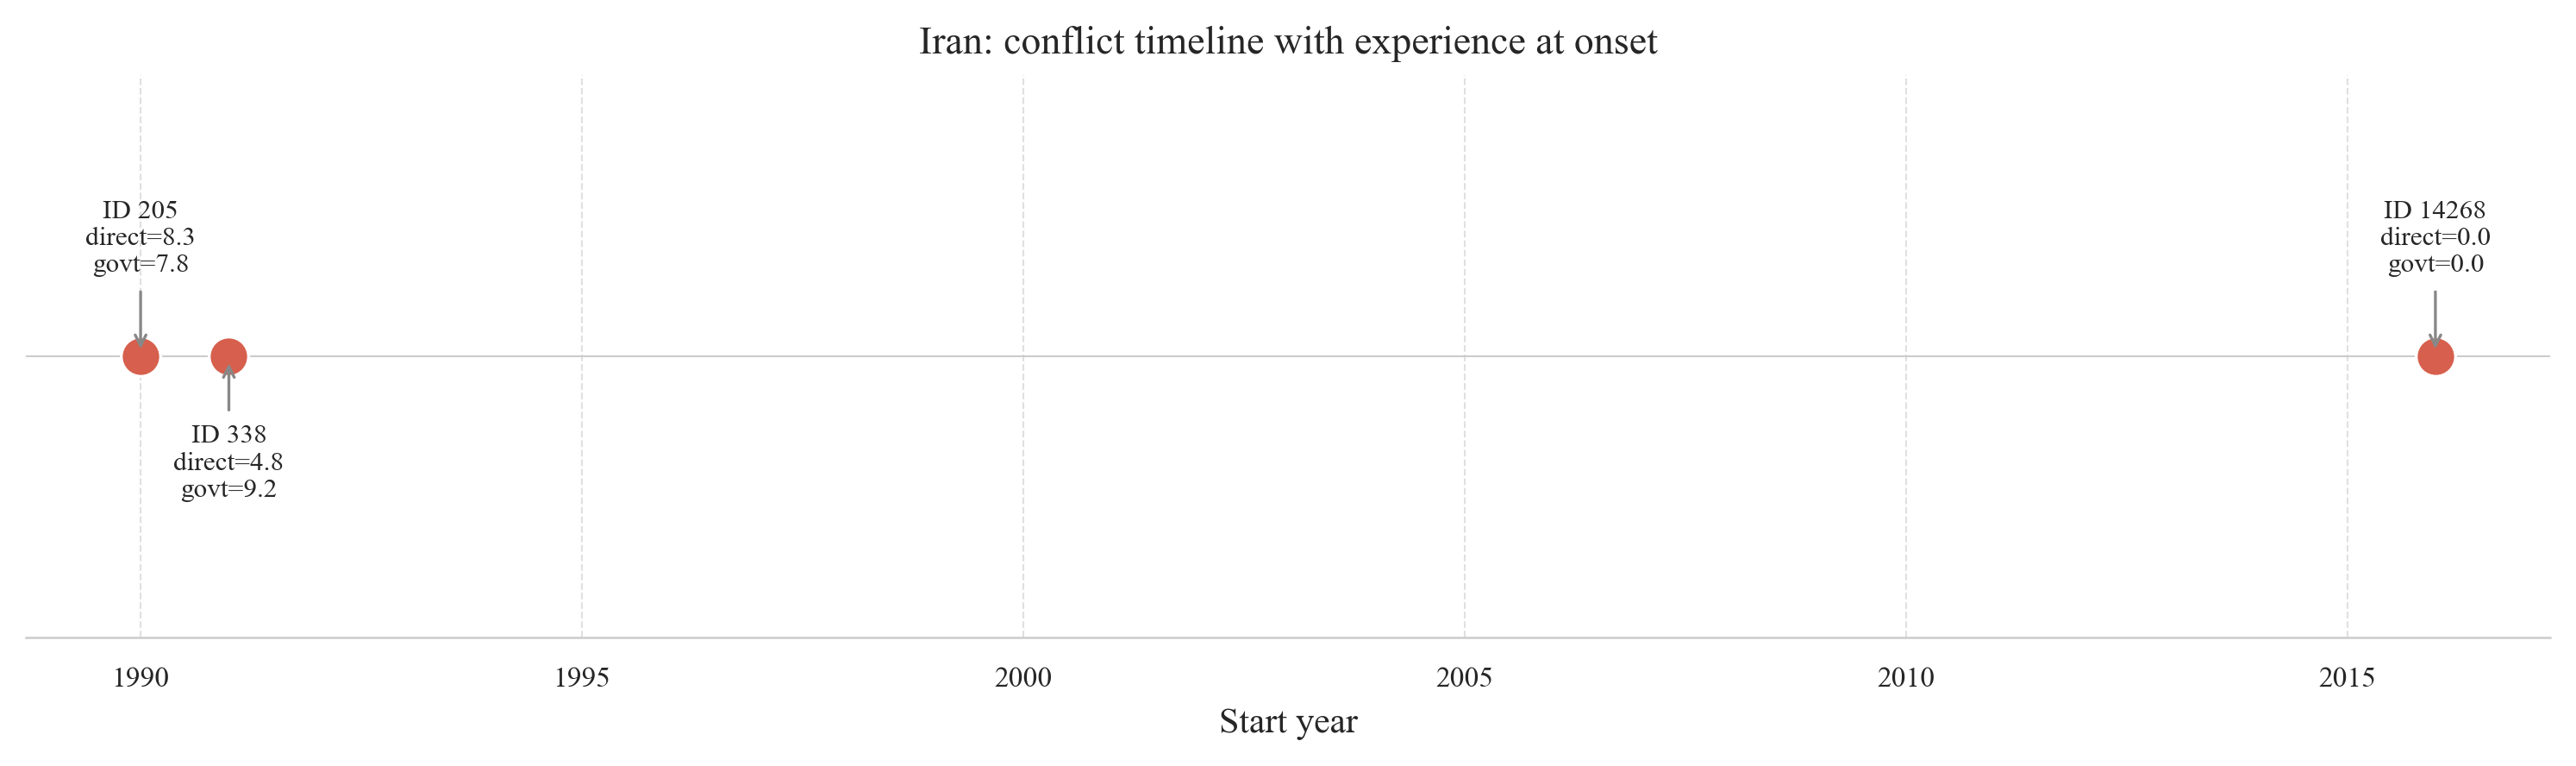

In [67]:
# ============================================================
# USE CASE: timeline de un país (ej. Colombia)
# ============================================================
conflict_level['start_year'] = df_panel.groupby('conflict_id')['start_year'].first().values.astype(int)
country_show = "Iran"
country_conflicts = conflict_level[
    conflict_level["country"] == country_show
][["conflict_id", "country", "start_year", "experience_direct",
   "experience_government", "experience_total_fighting", "ever_agreement"]]

print(f"\n{country_show}: {len(country_conflicts)} conflicts")
print(country_conflicts.to_string(index=False))

# Timeline plot
fig, ax = plt.subplots(figsize=(10, 3))
for i, (_, row) in enumerate(country_conflicts.iterrows()):
    color = "#2CA25F" if row["ever_agreement"] else "#D6604D"
    marker = "s" if row["ever_agreement"] else "o"
    ax.scatter(row["start_year"], 0, s=120, c=color, marker=marker, 
               zorder=3, edgecolors="white")
    ax.annotate(
        f"ID {int(row['conflict_id'])}\n"
        f"direct={row['experience_direct']:.1f}\n"
        f"govt={row['experience_government']:.1f}",
        xy=(row["start_year"], 0),
        xytext=(row["start_year"], 0.15 if i % 2 == 0 else -0.25),
        ha="center", fontsize=7.5,
        arrowprops=dict(arrowstyle="->", color="#888", lw=0.8)
    )
ax.axhline(0, color="#ccc", lw=0.5)
ax.set_yticks([])
ax.set_xlabel("Start year", fontsize=10)
ax.set_title(f"{country_show}: conflict timeline with experience at onset",
             fontsize=11)
ax.set_ylim(-0.5, 0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
plt.tight_layout()
plt.show()

### **PCA to IAI**

In [68]:
conflict_level[['conflict_id', 'territorial', 'inverse_total_experience']]

,conflict_id,territorial,inverse_total_experience
0,205,1,0.238474
1,209,0,0.243157
2,218,1,0.257193
3,220,0,0.842493
4,221,1,0.216649
...,...,...,...
196,16038,0,0.300240
197,16069,0,0.263318
198,16099,1,1.000000
199,16292,1,0.412199


In [69]:
min_max_scaler = MinMaxScaler()

conflict_level["info_index"] = min_max_scaler.fit_transform(
    conflict_level[["inverse_total_experience"]]
)

info_median = (
    conflict_level["info_index"]
    .median()
)

conflict_level["high_info_asymmetry"] = np.where(
    conflict_level["info_index"] >= info_median,
    "High information asymmetry",
    "Low information asymmetry"
)

## **Relative Indices**
---

In [70]:
conflict_level["ia_relative"] = (conflict_level["info_index"]/(conflict_level["info_index"]+conflict_level["commit_index"]))
conflict_level["commit_relative"] = (conflict_level["commit_index"]/(conflict_level["info_index"]+conflict_level["commit_index"]))
conflict_level["ia_minus_cp"] = (conflict_level["info_index"]-conflict_level["commit_index"])

## Index vs Outcome

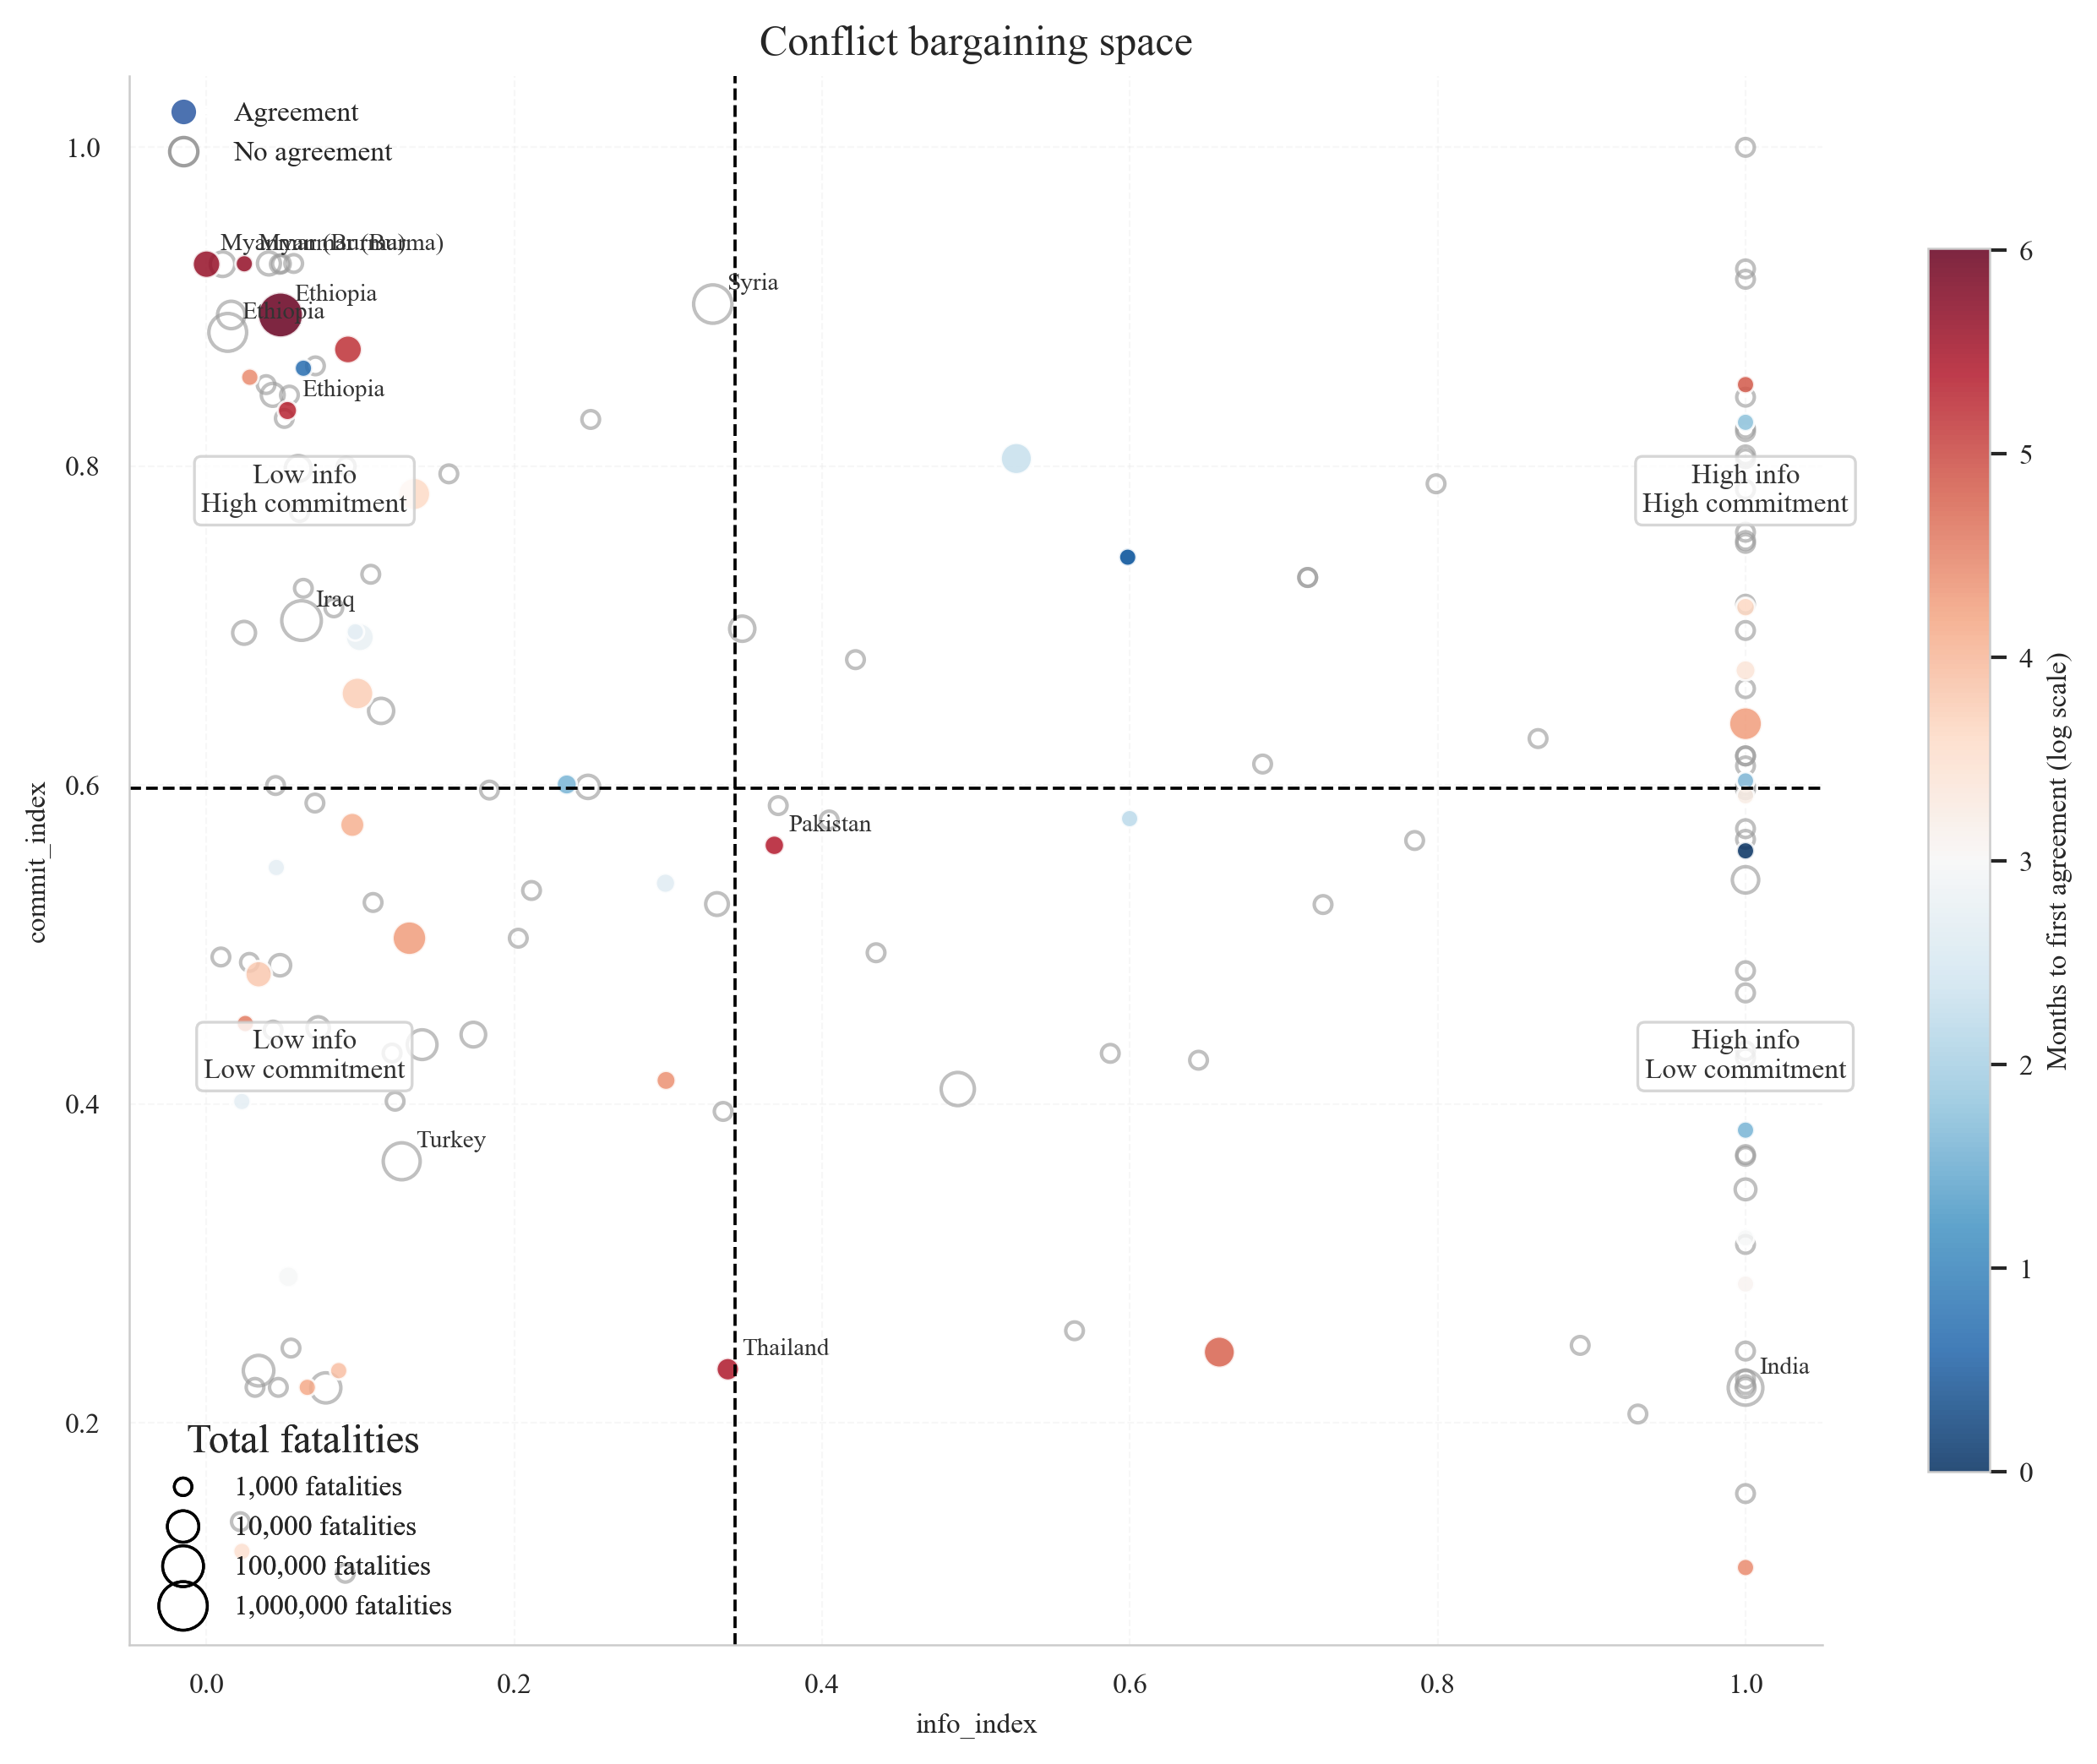

In [71]:
from functions.plot_bargaining_space import (
    plot_bargaining_space
)

fig, ax = plot_bargaining_space(
    df=conflict_level[conflict_level['type_of_conflict']=='interstate'],
    x="info_index",
    y="commit_index",
    title="Conflict bargaining space"
)

In [72]:
# Columnas principales
x = "info_index"
y = "commit_index"

id_col = "conflict_id"
outcome_col = "termination_outcome_group"  

# Orden deseado de cuadrantes
quadrant_order = [
    "High info / High commitment",
    "Low info / High commitment",
    "High info / Low commitment",
    "Low info / Low commitment"
]

# Copia del dataframe
quad_df = conflict_level.copy()

# Eliminar observaciones sin índices para evitar "Missing index"
quad_df = quad_df.dropna(subset=[x, y]).copy()

# Mismas medianas que usa tu gráfico para trazar las líneas
x_med = quad_df[x].median()
y_med = quad_df[y].median()

# Crear columna de cuadrante
quad_df["quadrant"] = pd.NA

quad_df.loc[
    (quad_df[x] >= x_med) & (quad_df[y] >= y_med),
    "quadrant"
] = "High info / High commitment"

quad_df.loc[
    (quad_df[x] < x_med) & (quad_df[y] >= y_med),
    "quadrant"
] = "Low info / High commitment"

quad_df.loc[
    (quad_df[x] >= x_med) & (quad_df[y] < y_med),
    "quadrant"
] = "High info / Low commitment"

quad_df.loc[
    (quad_df[x] < x_med) & (quad_df[y] < y_med),
    "quadrant"
] = "Low info / Low commitment"

# Ordenar cuadrantes
quad_df["quadrant"] = pd.Categorical(
    quad_df["quadrant"],
    categories=quadrant_order,
    ordered=True
)

## **Number of conflicts by quadrant**

In [73]:
conflicts_by_quadrant = (
    quad_df
    .groupby("quadrant", observed=False)[id_col]
    .nunique()
    .reindex(quadrant_order)
    .reset_index(name="n_conflicts")
)

display(conflicts_by_quadrant)

,quadrant,n_conflicts
0,High info / High commitment,49
1,Low info / High commitment,52
2,High info / Low commitment,52
3,Low info / Low commitment,48


## **Number of conflicts by quadrant and termination group**

In [74]:
conflicts_by_quadrant_outcome = pd.crosstab(
    index=quad_df["quadrant"],
    columns=quad_df[outcome_col],
    values=quad_df[id_col],
    aggfunc="nunique",
    dropna=False
).reindex(quadrant_order).fillna(0).astype(int).T

conflicts_by_quadrant_outcome["Total"] = conflicts_by_quadrant_outcome.sum(axis=1)

display(conflicts_by_quadrant_outcome)

quadrant,High info / High commitment,Low info / High commitment,High info / Low commitment,Low info / Low commitment,Total
termination_outcome_group,,,,,
Actor ceases,2,1,5,3,11
Agreement,7,4,8,2,21
Ceasefire,3,3,8,9,23
Low activity,14,22,13,20,69
Military victory,16,14,13,7,50
Ongoing / censored,7,8,5,7,27


## **Number of conflict by termination group**

In [75]:
conflicts_by_outcome = (
    quad_df
    .groupby([outcome_col, 'type_of_conflict'])[id_col]
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name="n_conflicts")
)

display(conflicts_by_outcome)

,termination_outcome_group,type_of_conflict,n_conflicts
0,Low activity,interstate,55
1,Military victory,interstate,38
2,Ceasefire,interstate,20
3,Ongoing / censored,interstate,15
4,Agreement,interstate,14
5,Low activity,internationalized_intrastate,10
6,Military victory,internationalized_intrastate,8
7,Ongoing / censored,internationalized_intrastate,8
8,Actor ceases,interstate,8
9,Military victory,intrastate,4


In [76]:
agreement_termination = pd.crosstab(
    index=conflict_level["termination_outcome_group"],
    columns=conflict_level['ever_agreement'],
    values=conflict_level['conflict_id'],
    aggfunc="nunique",
    dropna=False
)
agreement_termination["Total"] = agreement_termination.sum(axis=1)
agreement_termination

ever_agreement,0,1,Total
termination_outcome_group,,,
Actor ceases,6,5,11
Agreement,6,15,21
Ceasefire,11,12,23
Low activity,54,15,69
Military victory,39,11,50
Ongoing / censored,19,8,27


# **Run Logit regresions**



In [77]:
conflict_level['region_Middle_East'] = conflict_level['region_Middle East']

## **Baseline**

In [78]:
pd.crosstab(
    index=conflict_level['type_of_conflict'],
    columns=conflict_level['ever_agreement'],
    values=conflict_level['conflict_id'],
    aggfunc="nunique",
    dropna=False
).fillna(0).astype(int)

ever_agreement,0,1
type_of_conflict,,
internationalized_intrastate,18,16
interstate,105,45
intrastate,12,5


In [79]:
from functions.run_logit import run_logit

region_vars = [col for col in conflict_level.columns if col.startswith("region_") and " " not in col]

# Modelo 0 — replicación baseline
m0, t0 = run_logit(
    formula = "ever_agreement ~ log_total_deaths + duration_years + peak_monthly_deaths + " + " + ".join(region_vars) + "+ multiple_conflicts_binary",
    data    = conflict_level[conflict_level['type_of_conflict']=='interstate'],
    label   = "Modelo 0: Baseline",
)


════════════════════════════════════════════════════════════════════════
  Modelo 0: Baseline
  Formula : ever_agreement ~ log_total_deaths + duration_years + peak_monthly_deaths + region_Americas + region_Asia + region_Europe + region_Middle_East+ multiple_conflicts_binary
  N = 150 | Events = 45 | McFadden R² = 0.104
  Log-likelihood = -82.1 | LLR p-value = 0.0144
────────────────────────────────────────────────────────────────────────
  Variable                                 OR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_total_deaths                      1.225   0.151    0.911    1.646    1.35   0.179  
  duration_years                        1.029   0.017    0.996    1.063    1.74   0.082  .
  peak_monthly_deaths                   1.000   0.000    1.000    1.000    0.58   0.559  
  region_Americas                       1.693   0.784    0.365    7.866    0.67   0.501  
  region_Asia                 

## **Baseline + info_index**

In [81]:
# Modelo 1 — replicación baseline + commit
conflict_level["initial_ia"]   = 1.0 / (1.0 + conflict_level["experience_total_ihs"])
#binary version of initial_ia like high_info_asymmetry but with the median of initial_ia instead of info_index
conflict_level["high_initial_ia"] = np.where(
    conflict_level["initial_ia"] >= conflict_level["initial_ia"].median(),
    1,
    0
)

m1, t1 = run_logit(
    formula = "ever_agreement ~ log_total_deaths + duration_years +peak_monthly_deaths + " + " + ".join(region_vars) + " +multiple_conflicts_binary + high_initial_ia ",
    data    = conflict_level[conflict_level['type_of_conflict']=='interstate'],
    label   = "Model 1: Baseline + high_initial_ia ",
)


════════════════════════════════════════════════════════════════════════
  Model 1: Baseline + high_initial_ia 
  Formula : ever_agreement ~ log_total_deaths + duration_years +peak_monthly_deaths + region_Americas + region_Asia + region_Europe + region_Middle_East +multiple_conflicts_binary + high_initial_ia 
  N = 150 | Events = 45 | McFadden R² = 0.104
  Log-likelihood = -82.1 | LLR p-value = 0.0245
────────────────────────────────────────────────────────────────────────
  Variable                                 OR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_total_deaths                      1.223   0.152    0.908    1.648    1.33   0.185  
  duration_years                        1.029   0.017    0.996    1.064    1.71   0.087  .
  peak_monthly_deaths                   1.000   0.000    1.000    1.000    0.58   0.561  
  region_Americas                       1.683   0.792    0.356    7.950    0.66   0.

In [82]:
# Modelo 1 — replicación baseline + commit
m1, t1 = run_logit(
    formula = "ever_agreement ~ log_total_deaths + peak_monthly_deaths+duration_years + " + " + ".join(region_vars) + " +multiple_conflicts_binary + high_initial_ia + commit_index ",
    data    = conflict_level[conflict_level['type_of_conflict']=='interstate'],
    label   = "Model 1: Baseline + high_initial_ia + commit_index ",
)


════════════════════════════════════════════════════════════════════════
  Model 1: Baseline + high_initial_ia + commit_index 
  Formula : ever_agreement ~ log_total_deaths + peak_monthly_deaths+duration_years + region_Americas + region_Asia + region_Europe + region_Middle_East +multiple_conflicts_binary + high_initial_ia + commit_index 
  N = 150 | Events = 45 | McFadden R² = 0.104
  Log-likelihood = -82.1 | LLR p-value = 0.0392
────────────────────────────────────────────────────────────────────────
  Variable                                 OR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_total_deaths                      1.224   0.152    0.908    1.649    1.33   0.184  
  peak_monthly_deaths                   1.000   0.000    1.000    1.000    0.57   0.568  
  duration_years                        1.029   0.017    0.996    1.064    1.71   0.086  .
  region_Americas                       1.680   0.793  

In [83]:
# Modelo 2 — replicación baseline + COMMIT_VARS 
COMMIT_VARS = ['weak_state_preconflict',
 'weak_judicial_preconflict',
 #'weak_legislative_preconflict',
 'weak_accountability_preconflict',
 'weak_political_stability_preconflict']
m2, t2 = run_logit(
    formula = "ever_agreement ~ log_total_deaths + peak_monthly_deaths+duration_years  + " + " + ".join(region_vars) + "+ multiple_conflicts_binary + high_initial_ia + "+ " + ".join(COMMIT_VARS),
    data    = conflict_level[conflict_level['type_of_conflict']=='interstate'],
    label   = "Model 2: Baseline + COMMIT_VARS ",
)


════════════════════════════════════════════════════════════════════════
  Model 2: Baseline + COMMIT_VARS 
  Formula : ever_agreement ~ log_total_deaths + peak_monthly_deaths+duration_years  + region_Americas + region_Asia + region_Europe + region_Middle_East+ multiple_conflicts_binary + high_initial_ia + weak_state_preconflict + weak_judicial_preconflict + weak_accountability_preconflict + weak_political_stability_preconflict
  N = 150 | Events = 45 | McFadden R² = 0.146
  Log-likelihood = -78.2 | LLR p-value = 0.0132
────────────────────────────────────────────────────────────────────────
  Variable                                 OR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_total_deaths                      1.236   0.162    0.900    1.698    1.31   0.190  
  peak_monthly_deaths                   1.000   0.000    1.000    1.001    0.74   0.458  
  duration_years                        1.032   0.017 

In [34]:
# Modelo 2 — replicación baseline + COMMIT_VARS 
COMMIT_VARS = [#'weak_state_preconflict',
 'weak_judicial_preconflict',
 #'weak_legislative_preconflict',
 'weak_accountability_preconflict',
 'weak_political_stability_preconflict']

#apply sstandard scaler to the COMMIT_VARS
scaler = StandardScaler()
conflict_level[COMMIT_VARS] = scaler.fit_transform(conflict_level[COMMIT_VARS])
conflict_level['commit_index_zscore'] = conflict_level[COMMIT_VARS].mean(axis=1)
conflict_level['high_commit_index_zscore'] = np.where(
    conflict_level['commit_index_zscore'] >= conflict_level['commit_index_zscore'].median(),
    1,
    0
).astype(int)

m2, t2 = run_logit(
    formula = "ever_agreement ~ log_total_deaths + duration_years  + " + " + ".join(region_vars) + "+ multiple_conflicts_binary + high_commit_index_zscore + high_initial_ia",
    data    = conflict_level[conflict_level['type_of_conflict']=='interstate'],
    label   = "Model 2: Baseline + COMMIT_VARS ",
)


════════════════════════════════════════════════════════════════════════
  Model 2: Baseline + COMMIT_VARS 
  Formula : ever_agreement ~ log_total_deaths + duration_years  + region_Americas + region_Asia + region_Europe + region_Middle_East+ multiple_conflicts_binary + high_commit_index_zscore + high_initial_ia
  N = 150 | Events = 45 | McFadden R² = 0.099
  Log-likelihood = -82.5 | LLR p-value = 0.0329
────────────────────────────────────────────────────────────────────────
  Variable                                 OR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_total_deaths                      1.304   0.126    1.018    1.671    2.10   0.036  *
  duration_years                        1.027   0.016    0.995    1.061    1.66   0.097  .
  region_Americas                       1.590   0.792    0.337    7.502    0.59   0.558  
  region_Asia                           1.416   0.510    0.521    3.849    0.68  

## Define commit_index with variables during conlfict


In [35]:
conflict_level["weak_state"] = (-conflict_level["state_territorial_control"])
conflict_level["weak_accountability"] = (-conflict_level["horiz_accountability"])
#conflict_level["weak_legislative"] = (-conflict_level["legislative_constraints"])
conflict_level["weak_judicial"] = (-conflict_level["judicial_constraints"])
conflict_level['weak_political_stability'] = (-conflict_level["political_stability"]) 

conflict_level['low_regime'] = -conflict_level['regime_type']
COMMIT_VARS = [
    "weak_state",
    "weak_judicial",
    #"weak_legislative",
    "weak_accountability",
    "weak_political_stability",
    #"low_regime"
]

#fill missing values with the mean of each variable per conflict
conflict_level[COMMIT_VARS] = conflict_level[COMMIT_VARS].fillna(conflict_level[COMMIT_VARS].mean())

scaler = StandardScaler()
X_cp = scaler.fit_transform(
    conflict_level[COMMIT_VARS]
)


pca_cp = PCA(n_components=1)

conflict_level["commit_index_during_conflict"] = (
    pca_cp.fit_transform(X_cp)[:, 0]
)

loadings = pd.DataFrame(
    pca_cp.components_.T,
    columns=["PC1"],
    index=COMMIT_VARS
)

print(loadings)
print("\n Explained Variance Ratio:", pca_cp.explained_variance_ratio_)

min_max_scaler = MinMaxScaler()

conflict_level["commit_index_during_conflict"] = min_max_scaler.fit_transform(
    conflict_level[["commit_index_during_conflict"]]
)

conflict_level["high_commitment"] = np.where(
    conflict_level["commit_index_during_conflict"]>=conflict_level["commit_index_during_conflict"].median(),
    1,
    0
)

                               PC1
weak_state                0.420811
weak_judicial             0.570149
weak_accountability       0.549379
weak_political_stability  0.442754

 Explained Variance Ratio: [0.55646823]


In [36]:
# Modelo 3 — replicación baseline + commit
m3, t3 = run_logit(
    formula = "ever_agreement ~ log_total_deaths + duration_years + peak_monthly_deaths + " + " + ".join(region_vars) + "+ multiple_conflicts_binary + commit_index_during_conflict + high_initial_ia",
    data    = conflict_level[conflict_level['type_of_conflict']=='interstate'],
    label   = "Model 3: Baseline + commit_index (during conflict) ",
)


════════════════════════════════════════════════════════════════════════
  Model 3: Baseline + commit_index (during conflict) 
  Formula : ever_agreement ~ log_total_deaths + duration_years + peak_monthly_deaths + region_Americas + region_Asia + region_Europe + region_Middle_East+ multiple_conflicts_binary + commit_index_during_conflict + high_initial_ia
  N = 150 | Events = 45 | McFadden R² = 0.119
  Log-likelihood = -80.8 | LLR p-value = 0.0164
────────────────────────────────────────────────────────────────────────
  Variable                                 OR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_total_deaths                      1.206   0.148    0.902    1.612    1.26   0.207  
  duration_years                        1.035   0.017    1.001    1.071    2.01   0.045  *
  peak_monthly_deaths                   1.000   0.000    1.000    1.000    0.54   0.592  
  region_Americas                     

In [37]:
# Modelo 3 — replicación baseline + commit
m3, t3 = run_logit(
    formula = "ever_agreement ~ log_total_deaths + duration_years + peak_monthly_deaths + " + " + ".join(region_vars) + "+ multiple_conflicts_binary + high_commitment + high_initial_ia",
    data    = conflict_level[conflict_level['type_of_conflict']=='interstate'],
    label   = "Model 3: Baseline + commit_index (during conflict) ",
)


════════════════════════════════════════════════════════════════════════
  Model 3: Baseline + commit_index (during conflict) 
  Formula : ever_agreement ~ log_total_deaths + duration_years + peak_monthly_deaths + region_Americas + region_Asia + region_Europe + region_Middle_East+ multiple_conflicts_binary + high_commitment + high_initial_ia
  N = 150 | Events = 45 | McFadden R² = 0.115
  Log-likelihood = -81.1 | LLR p-value = 0.0211
────────────────────────────────────────────────────────────────────────
  Variable                                 OR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_total_deaths                      1.217   0.148    0.910    1.628    1.32   0.186  
  duration_years                        1.033   0.017    0.999    1.069    1.93   0.054  .
  peak_monthly_deaths                   1.000   0.000    1.000    1.000    0.52   0.605  
  region_Americas                       1.804   0.7

In [38]:
# Modelo 4 — replicación baseline + COMMIT_VARS 
m4, t4 = run_logit(
    formula = "ever_agreement ~ log_total_deaths + duration_years + peak_monthly_deaths + " + " + ".join(region_vars) + "+ multiple_conflicts_binary + high_initial_ia+"+ " + ".join(COMMIT_VARS),
    data    = conflict_level[conflict_level['type_of_conflict']=='interstate'],
    label   = "Model 4: Baseline + COMMIT_VARS (during conflict) ",
)


════════════════════════════════════════════════════════════════════════
  Model 4: Baseline + COMMIT_VARS (during conflict) 
  Formula : ever_agreement ~ log_total_deaths + duration_years + peak_monthly_deaths + region_Americas + region_Asia + region_Europe + region_Middle_East+ multiple_conflicts_binary + high_initial_ia+weak_state + weak_judicial + weak_accountability + weak_political_stability
  N = 150 | Events = 45 | McFadden R² = 0.196
  Log-likelihood = -73.6 | LLR p-value = 0.0006
────────────────────────────────────────────────────────────────────────
  Variable                                 OR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_total_deaths                      1.085   0.170    0.777    1.515    0.48   0.631  
  duration_years                        1.053   0.020    1.013    1.095    2.60   0.009  **
  peak_monthly_deaths                   1.000   0.000    1.000    1.001    0.75   0

In [39]:
COMMIT_VARS = [
    #"weak_state",
    "weak_judicial",
    #"weak_legislative",
    #"weak_accountability",
   # "weak_political_stability",
    #"low_regime"
]

In [40]:
scaler = StandardScaler()

Z_info = pd.DataFrame(
    scaler.fit_transform(conflict_level[["weak_state", "weak_political_stability"]]),
    columns=["weak_state", "weak_political_stability"],
    index=conflict_level.index
)

conflict_level["commit_index_z"] = Z_info.mean(axis=1)

conflict_level["commit_index_z"] = MinMaxScaler().fit_transform(
    conflict_level[["commit_index_z"]]
)

# Modelo 2 — replicación baseline + COMMIT_VARS 
m2, t2 = run_logit(
    formula = "ever_agreement ~ log_total_deaths + " + " + ".join(region_vars) + "+ multiple_conflicts_binary +"+ " + ".join(COMMIT_VARS),
    data    = conflict_level,
    label   = "Model 2: Baseline + COMMIT_VARS ",
)


════════════════════════════════════════════════════════════════════════
  Model 2: Baseline + COMMIT_VARS 
  Formula : ever_agreement ~ log_total_deaths + region_Americas + region_Asia + region_Europe + region_Middle_East+ multiple_conflicts_binary +weak_judicial
  N = 201 | Events = 66 | McFadden R² = 0.080
  Log-likelihood = -117.0 | LLR p-value = 0.0048
────────────────────────────────────────────────────────────────────────
  Variable                                 OR      SE   CI_low  CI_high       z       p  sig
────────────────────────────────────────────────────────────────────────
  log_total_deaths                      1.350   0.093    1.125    1.621    3.22   0.001  **
  region_Americas                       1.502   0.669    0.405    5.570    0.61   0.543  
  region_Asia                           1.573   0.404    0.713    3.471    1.12   0.262  
  region_Europe                         3.731   0.475    1.470    9.466    2.77   0.006  **
  region_Middle_East                

In [47]:
df_plot.experience_government

0       7.787599
1      12.888065
3       0.188044
4      16.680356
5      16.796338
         ...    
195     0.000000
196    10.187564
197    16.345710
199     3.921809
200    14.501418
Name: experience_government, Length: 150, dtype: float64

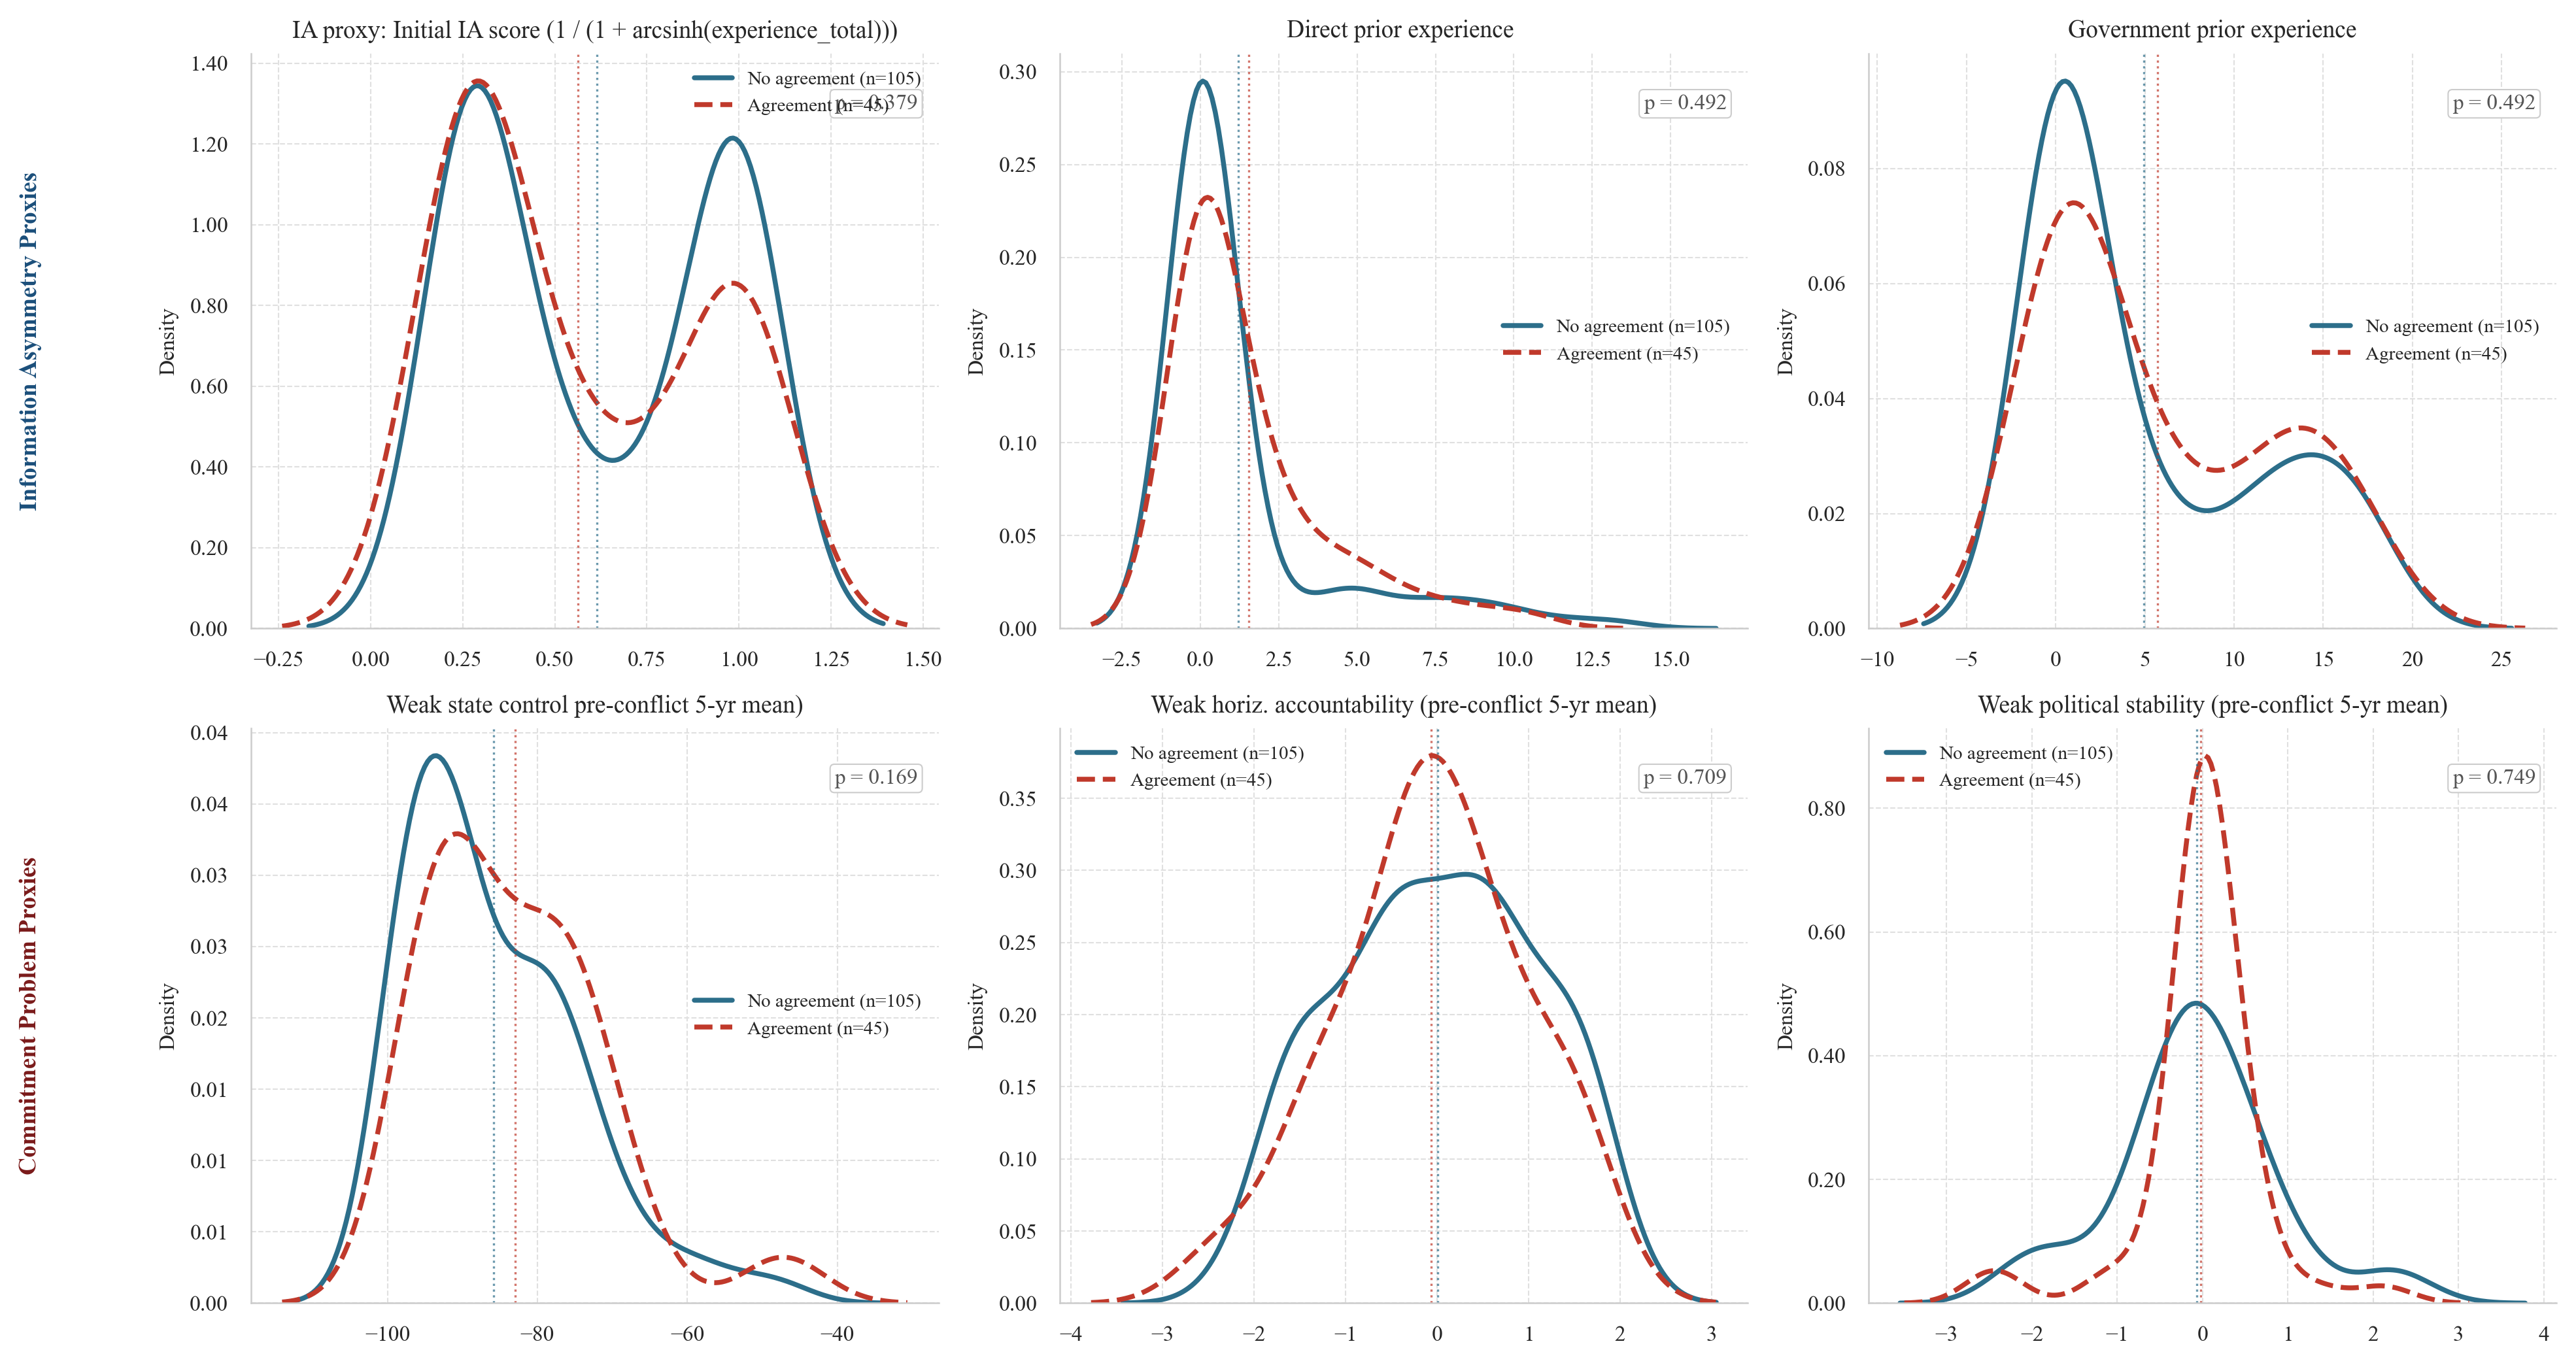

In [49]:
# ============================================================
# KDE FIGURES — IA and CP proxies by agreement outcome
# ============================================================
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker



df_plot = conflict_level[conflict_level['type_of_conflict'] == 'interstate'].copy()

IA_VARS = [
    ("initial_ia", "IA proxy: Initial IA score (1 / (1 + arcsinh(experience_total)))"),
     ("experience_direct","Direct prior experience "),
    ("experience_government",  "Government prior experience"),
   
    
]

CP_VARS = [
    ("weak_state_preconflict","Weak state control pre-conflict 5-yr mean)"),
    ("weak_accountability_preconflict",    "Weak horiz. accountability (pre-conflict 5-yr mean)"),
    ("weak_political_stability_preconflict","Weak political stability (pre-conflict 5-yr mean)"),
]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

for ax, (var, label) in zip(axes[0], IA_VARS):
    plot_kde_by_agreement(
        df=df_plot, variable=var, label=label,
        ax=ax, color_noagr=C_NOAGR, color_agr=C_AGR
    )

for ax, (var, label) in zip(axes[1], CP_VARS):
    plot_kde_by_agreement(
        df=df_plot, variable=var, label=label,
        ax=ax, color_noagr=C_NOAGR, color_agr=C_AGR
    )

# Row labels
for ax_row, row_label, color in [
    (axes[0], "Information Asymmetry Proxies", "#1a4e7a"),
    (axes[1], "Commitment Problem Proxies",    "#7a1a1a"),
]:
    ax_row[0].set_ylabel("Density", fontsize=8)
    ax_row[0].annotate(
        row_label, xy=(-0.32, 0.5), xycoords="axes fraction",
        fontsize=9, fontweight="bold", color=color,
        rotation=90, va="center", ha="center"
    )


for ax in axes.flat:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()


plt.show()
